# DATA DESCRIPTION

***

- **T1w.nii**  --> structural T1-weighted image (3D)

***

- **mask.nii** --> brain mask, derived from a brain extraction procedure on the T1w data. This is a binary map, with the same dimension of the corresponding T1w

***

- **fMRI.nii** --> functional MRI data (4D), where each brain volume has been acquired multiple times. This is the fourth dimension of the fMRI data. The TR (repetition time, i.e. time between consecutive time points) is 3.5 sec.

***

- **MNI152_T1_2mm_brain.nii** --> common anatomical MNI space (MNI-2mm), 3D structure

***

- **Schaefer2018_200Parcels_7Networks_order_FSLMNI152_2mm.nii** --> reference brain atlas, consisting of 200 brain regions derived from a functional parcellation of the brain voxels/tissues, 3D structure of same dimension of anatomical MNI space

***

# PART 0
***
This part prior to the real analysis pipeline is performed to do some data exploration before starting with the real project. The aim is to gain familiarity with the data so that further examination will be much easier

- .nii format --> Neuroimaging Informatics Technology Initiative (NifTI): main standard used to archive, analyze and share brain scans (TAC, fMRI...) allowing the collection of volumetric images and temporal information in a unique file

In [13]:
# Let's add all the necessary imports in a unique cell

import nibabel as nib
import os
import matplotlib.pyplot as plt
import numpy as np

In [14]:
# os can be used to manage paths to files... these are the paths needed

PROJECT_PATH     = os.path.dirname(os.path.abspath(__name__)) # extract directory of this file
DATA_PATH        = os.path.join(os.getcwd(), "data")
T1_PATH          = os.path.join(DATA_PATH, "T1w.nii")
MASK_PATH        = os.path.join(DATA_PATH, "mask.nii")
FMRI_PATH        = os.path.join(DATA_PATH, "fMRI.nii")
MNI_PATH         = os.path.join(DATA_PATH, "MNI152_T1_2mm_brain.nii")
ATLAS_PATH       = os.path.join(DATA_PATH, "Schaefer2018_200Parcels_7Networks_order_FSLMNI152_2mm.nii")
REGIONS_CSV_PATH = os.path.join(DATA_PATH, "Schaefer2018_200Parcels_7Networks_order_FSLMNI152_2mm.Centroid_RAS.csv")

## Functions

In [34]:
def load_and_display(nii_path: str, name: str):
    """
    Input:
    - nii_path: path to the .nii file
    - name: descriptive name for the display of info

    Return: dict data, header data, img data and dimension of the img
    """

    nii_img = nib.load(nii_path)
    nii_hdr = nii_img.header
    nii_data = nii_img.get_fdata()
    nii_dim = nii_hdr['dim'][:4]

    voxel_size = tuple(round(float(v),3) for v in nii_hdr.get_zooms())
    
    print(f"\nINFORMATION ABOUT {name} NIFTI FILE:")
    print("\n"+"-"*100)
    
    print(f"Type of variable nii_img: {type(nii_img)}")
    print(f"Type of variable nii_hdr: {type(nii_hdr)}")
    print(f"Shape of the NIfTI image: {nii_img.shape}")
    print(f"Dimensions of the NIfTI image: {nii_dim}")
    print(f"Dimensions of NIfTI img data: {nii_data.shape}")
    print(f"Voxel size (mm): {voxel_size}")
    
    return nii_img, nii_hdr, nii_data, nii_dim


def _get_slice(nii_data, slice_idx, axis="axial", time_instant=0):
    """
    Auxiliary function: extracts a 2D slice from 3D or 4D nii_data,
    given the axis and slice index. Handles bounds checking via assert.

    Return: 2D slice, and the size of the volume along the chosen axis
            (useful for titles / labels).
    """
    axis_to_shape_idx = {"axial": 2, "sagittal": 1, "coronal": 0}
    
    if axis not in axis_to_shape_idx:
        raise ValueError('axis must be "axial", "sagittal" or "coronal"')
    
    shape_idx = axis_to_shape_idx[axis]
    n_slices = nii_data.shape[shape_idx]
    
    is_4d = len(nii_data.shape) > 3
    if is_4d:
        assert slice_idx < n_slices and time_instant < nii_data.shape[3], \
            "You need to choose a slice index < {} or a time instant < {}.".format(n_slices, nii_data.shape[3])
    else:
        assert slice_idx < n_slices, \
            "You need to choose a slice index < {}.".format(n_slices)
    
    if axis == "axial":
        slice_2d = nii_data[:, :, slice_idx, time_instant] if is_4d else nii_data[:, :, slice_idx]
    elif axis == "sagittal":
        slice_2d = nii_data[:, slice_idx, :, time_instant] if is_4d else nii_data[:, slice_idx, :]
    else:  # coronal
        slice_2d = nii_data[slice_idx, :, :, time_instant] if is_4d else nii_data[slice_idx, :, :]
    
    return slice_2d, n_slices


def display_single_slice(nii_data, slice_idx, axis="axial", time_instant=0):
    """
    Input: 
    - img data of some .nii file
    - slice_idx: index for a slice
    - axis: reference plane, choices are "axial" (default), "sagittal" and "coronal"
    - time_instant: to choose a time instant when nii_data.shape is > 3 (fMRI for example), default is 0

    Return: void, it visualizes the chosen slice
    """
    slice_2d, n_slices = _get_slice(nii_data, slice_idx, axis, time_instant)
    
    plt.figure(figsize=(6, 4))
    plt.imshow(np.rot90(slice_2d, 1), cmap='gray', vmin=np.min(slice_2d))
    plt.grid(False)
    plt.title('Single slice, n. {} of {}'.format(slice_idx, n_slices))
    plt.axis('off')
    plt.show()


def display_group_of_slices(nii_data, num_to_disp, starting_idx=0, sparse=False,
                              idxs_list=None, disp_step=1, axis="axial", time_instant=0,
                              max_cols=4):
    """
    Input: 
    - nii_data: data structure to display
    - num_to_disp: number of slices to display
    - starting_idx: first idx to display (used when sparse=False)
    - sparse: boolean, if True you can provide a list of idxs to display, if False starting idx and step are used (default = False)
    - idxs_list: list of indexes to display in case of sparse = True (default = None)
    - disp_step: step between one displayed slice and the next, used when sparse=False (default = 1)
    - axis: reference plane, "axial" (default), "sagittal" or "coronal"
    - time_instant: time point to use if nii_data is 4D (default = 0)
    - max_cols: maximum number of images per row (default = 4)

    Return: void, displays a grid of slices
    """
    axis_to_shape_idx = {"axial": 2, "sagittal": 1, "coronal": 0}
    if axis not in axis_to_shape_idx:
        raise ValueError('axis must be "axial", "sagittal" or "coronal"')
    n_slices_total = nii_data.shape[axis_to_shape_idx[axis]]

    # --- build the list of indices to display ---
    if sparse:
        if idxs_list is None:
            print("Nessuna lista fornita: scelgo io {} indici casuali.".format(num_to_disp))
            idxs_list = sorted(np.random.choice(n_slices_total, size=num_to_disp, replace=False))
        else:
            assert max(idxs_list) < n_slices_total, \
                "All indices in idxs_list must be < {}.".format(n_slices_total)
            num_to_disp = len(idxs_list)
        indices = idxs_list
    else:
        indices = [starting_idx + i * disp_step for i in range(num_to_disp)]
        assert max(indices) < n_slices_total, \
            "starting_idx + num_to_disp * disp_step exceeds the number of slices ({}).".format(n_slices_total)

    # --- build the grid ---
    n_cols = min(max_cols, num_to_disp)
    n_rows = int(np.ceil(num_to_disp / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.atleast_1d(axes).flatten()  # flatten anche se n_rows=1 o n_cols=1

    for ax, idx in zip(axes, indices):
        slice_2d, n_slices = _get_slice(nii_data, idx, axis, time_instant)
        ax.imshow(np.rot90(slice_2d, 1), cmap='gray', vmin=np.min(slice_2d))
        ax.set_title('Slice {} of {}'.format(idx, n_slices))
        ax.axis('off')

    # nascondi eventuali subplot vuoti in eccesso (griglia non piena)
    for ax in axes[len(indices):]:
        ax.axis('off')

    plt.suptitle('{} view — group of {} slices'.format(axis.capitalize(), num_to_disp))
    plt.tight_layout()
    plt.show()


def single_slice_hist(nii_data, mask_data, slice_idx, axis = "axial"):

    slice_2d, _ = _get_slice(nii_data, slice_idx, axis=axis)
    slice_1d = slice_2d.flatten()

    mask_slice, _ = _get_slice(mask_data, slice_idx, axis=axis)
    mask_slice = mask_slice.astype(bool)
    mask_slice_flattened = mask_slice.flatten()

    if mask_slice_flattened.sum() == 0:
        print(f"Attenzione: lo slice {slice_idx} non contiene voxel dentro la maschera.")
        return

    fig, axs = plt.subplots(1,2,figsize=(10,6))
    axs[0].hist(slice_1d, density=True, bins=255, range=(0,255))
    axs[0].set_title('Slice {} — no mask'.format(slice_idx))

    axs[1].hist(slice_1d[mask_slice_flattened], density=True, bins=255, range=(0,255))
    axs[1].set_title('Slice {} — masked'.format(slice_idx))

    plt.show()


def volume_hist(nii_data, mask_data=None, bins=255, hist_range=(0, 255)):
    """
    Input:
    - nii_data: volume 3D (o 4D, in tal caso serve specificare un singolo volume prima di chiamare la funzione)
    - mask_data: se fornita, l'istogramma viene calcolato solo sui voxel dentro la maschera (default None)
    - bins, hist_range: parametri passati a plt.hist

    Return: void, mostra l'istogramma del volume intero (masked vs unmasked se mask_data è fornita)
    """
    assert len(nii_data.shape) == 3, "volume_hist si aspetta un volume 3D. Se hai un 4D, seleziona prima un time point."
    
    data_flat = nii_data.flatten()

    if mask_data is None:
        plt.figure(figsize=(6, 4))
        plt.hist(data_flat, density=True, bins=bins, range=hist_range)
        plt.title('Volume histogram — no mask')
        plt.show()
        return

    assert nii_data.shape == mask_data.shape, "nii_data e mask_data devono avere la stessa shape."
    
    mask_flat = mask_data.astype(bool).flatten()
    
    if mask_flat.sum() == 0:
        print("Attenzione: la maschera fornita non contiene voxel True.")
        return

    fig, axs = plt.subplots(1, 2, figsize=(10, 6))
    axs[0].hist(data_flat, density=True, bins=bins, range=hist_range)
    axs[0].set_title('Volume histogram — no mask')

    axs[1].hist(data_flat[mask_flat], density=True, bins=bins, range=hist_range)
    axs[1].set_title('Volume histogram — masked')
    
    plt.show()


def avg_intensity(nii_data, mask_data=None, single_slice=True, slice_idx=None, axis="axial"):
    """
    Input:
    - nii_data: volume 3D
    - mask_data: se fornita, la media è calcolata solo sui voxel dentro la maschera (default None)
    - single_slice: se True calcola la media su un singolo slice, se False su tutto il volume (default True)
    - slice_idx: indice dello slice, richiesto se single_slice=True
    - axis: piano di riferimento se single_slice=True (default "axial")

    Return: float, intensità media
    """
    if single_slice:
        assert slice_idx is not None, "slice_idx è richiesto quando single_slice=True."
        data, _ = _get_slice(nii_data, slice_idx, axis=axis)
        if mask_data is not None:
            mask, _ = _get_slice(mask_data, slice_idx, axis=axis)
    else:
        data = nii_data
        mask = mask_data

    if mask_data is None:
        mean_val = np.mean(data)
    else:
        mask_bool = mask.astype(bool)
        if mask_bool.sum() == 0:
            print("Attenzione: la maschera non contiene voxel True in questa regione.")
            return None
        mean_val = np.mean(data[mask_bool])

    scope = f"slice {slice_idx} ({axis})" if single_slice else "intero volume"
    masked_str = "masked" if mask_data is not None else "unmasked"
    print(f"Intensità media ({masked_str}) — {scope}: {mean_val:.3f}")
    
    return mean_val


def avg_intensity_along_axis(nii_data, mask_data=None, axis="axial"):
    """
    Input:
    - nii_data: volume 3D
    - mask_data: se fornita, la media di ogni slice è calcolata solo sui voxel dentro la maschera (default None)
    - axis: piano lungo cui scorrere (default "axial")

    Return: 1D numpy array con l'intensità media per ogni slice lungo l'asse scelto;
            mostra anche il plot del profilo
    """
    axis_to_shape_idx = {"axial": 2, "sagittal": 1, "coronal": 0}
    if axis not in axis_to_shape_idx:
        raise ValueError('axis must be "axial", "sagittal" or "coronal"')
    
    n_slices = nii_data.shape[axis_to_shape_idx[axis]]
    means = np.zeros(n_slices)

    for i in range(n_slices):
        slice_2d, _ = _get_slice(nii_data, i, axis=axis)
        
        if mask_data is None:
            means[i] = np.mean(slice_2d)
        else:
            mask_slice, _ = _get_slice(mask_data, i, axis=axis)
            mask_bool = mask_slice.astype(bool)
            means[i] = np.mean(slice_2d[mask_bool]) if mask_bool.sum() > 0 else np.nan

    plt.figure(figsize=(8, 4))
    plt.plot(means)
    masked_str = "masked" if mask_data is not None else "unmasked"
    plt.title(f'Average intensity along {axis} axis ({masked_str})')
    plt.xlabel('Slice index')
    plt.ylabel('Mean intensity')
    plt.show()

    return means

In [ ]:
def avg_signal_along_time(data_4d, TR=None):
    """
    Input:
    - data_4d: volume fMRI 4D (x, y, z, t)
    - TR: repetition time in secondi, se fornito l'asse x è in secondi, altrimenti in indice di volume (default None)

    Return: 1D numpy array con la media globale del segnale per ogni istante temporale;
            mostra anche il plot del segnale nel tempo
    """
    n_timepoints = data_4d.shape[3]
    means = np.zeros(n_timepoints)

    for t in range(n_timepoints):
        means[t] = np.mean(data_4d[:, :, :, t])

    if TR is not None:
        time_pts = np.arange(n_timepoints) * TR
        xlabel = 'Time (s)'
    else:
        time_pts = np.arange(n_timepoints)
        xlabel = 'Time point index'

    plt.figure(figsize=(10, 6))
    plt.plot(time_pts, means)
    plt.xlabel(xlabel)
    plt.ylabel('Mean global signal')
    plt.title('Average signal over time')
    plt.show()

    return means

## T1-Weighted Analysis

In [16]:
t1_img, t1_hdr, t1_data, t1_dim = load_and_display(T1_PATH, "T1-WEIGHTED")


INFORMATION ABOUT T1-WEIGHTED NIFTI FILE:

----------------------------------------------------------------------------------------------------
Type of variable nii_img: <class 'nibabel.nifti1.Nifti1Image'>
Type of variable nii_hdr: <class 'nibabel.nifti1.Nifti1Header'>
Shape of the NIfTI image: (176, 256, 256)
Dimensions of the NIfTI image: [  3 176 256 256]
Dimensions of NIfTI img data: (176, 256, 256)
Voxel size (mm): (1.0, 0.977, 0.977)


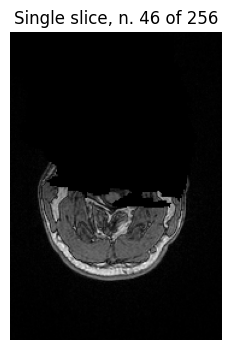

In [17]:
display_single_slice(t1_data, slice_idx=46, axis='axial') # axial = from the top, sagittal = from the back, coronal = from the side

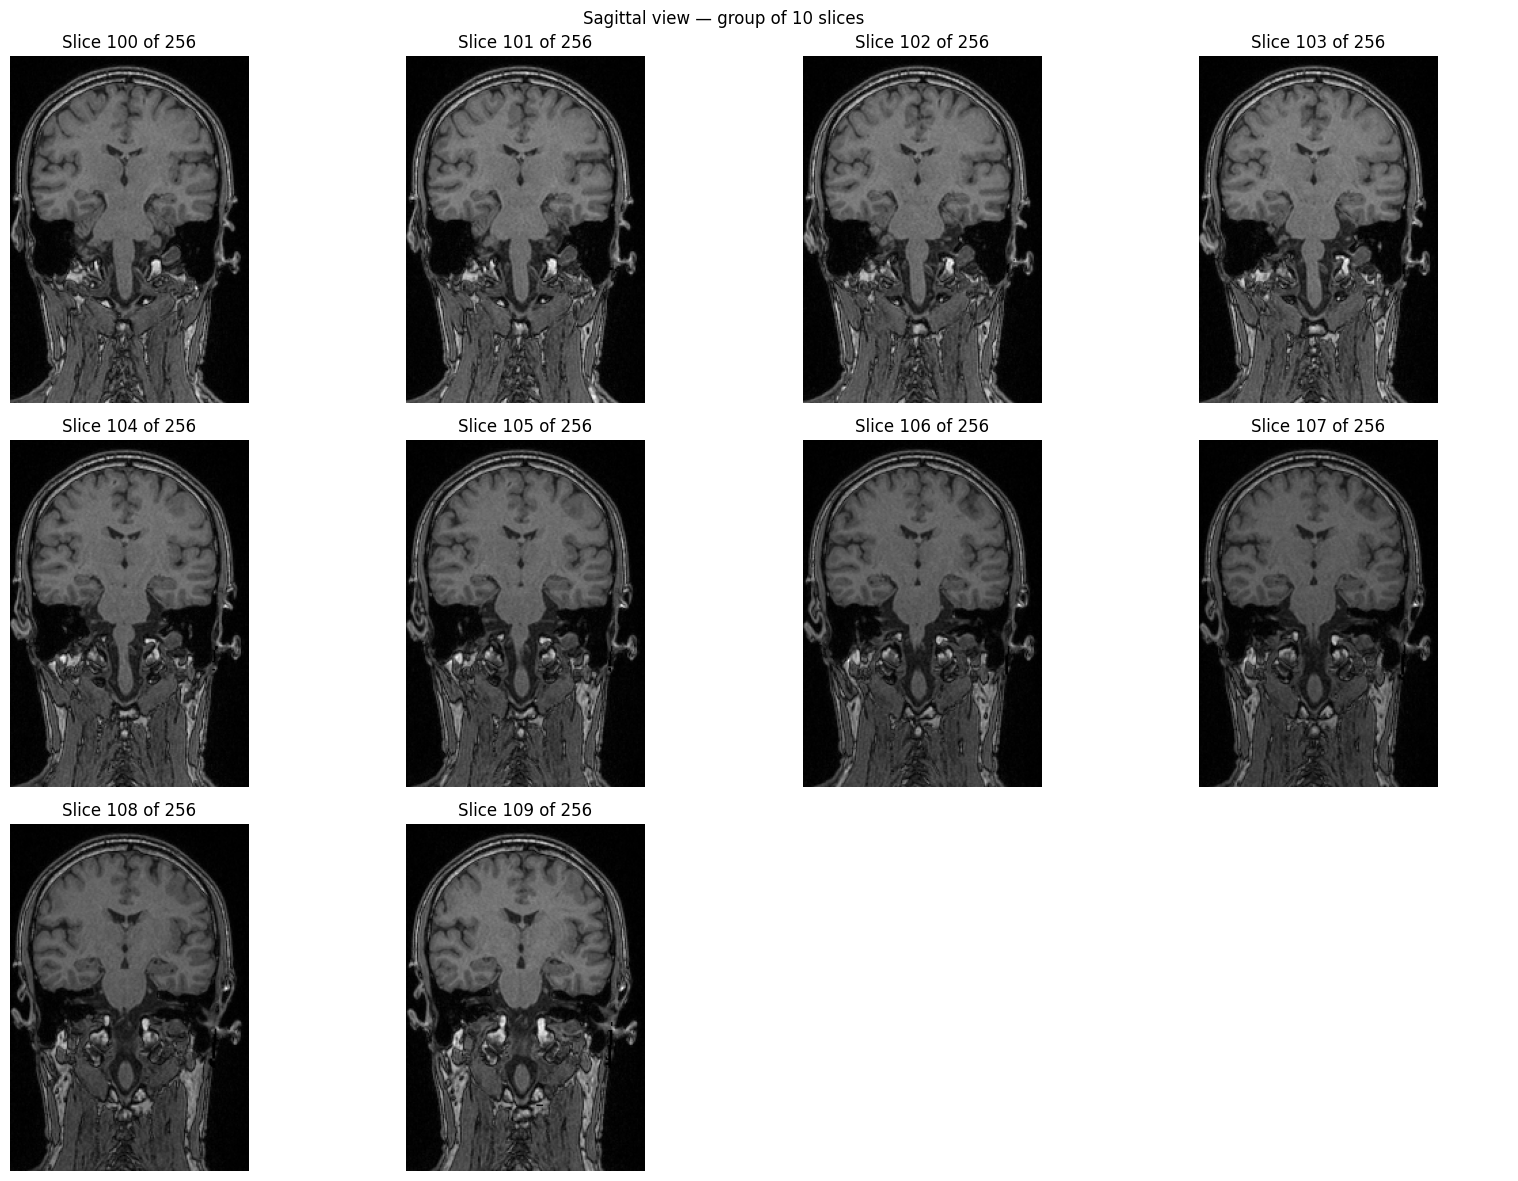

In [18]:
display_group_of_slices(t1_data, 10,starting_idx=100, axis="sagittal")

## Mask Analysis

In [19]:
mask, mask_hdr, mask_data, mask_dims = load_and_display(MASK_PATH, 'MASK')

print("\n")
print(f"Check of dimension equality between t1_data and mask_data: {t1_data.shape == mask_data.shape}")


INFORMATION ABOUT MASK NIFTI FILE:

----------------------------------------------------------------------------------------------------
Type of variable nii_img: <class 'nibabel.nifti1.Nifti1Image'>
Type of variable nii_hdr: <class 'nibabel.nifti1.Nifti1Header'>
Shape of the NIfTI image: (176, 256, 256)
Dimensions of the NIfTI image: [  3 176 256 256]
Dimensions of NIfTI img data: (176, 256, 256)
Voxel size (mm): (1.0, 0.977, 0.977)


Check of dimension equality between t1_data and mask_data: True


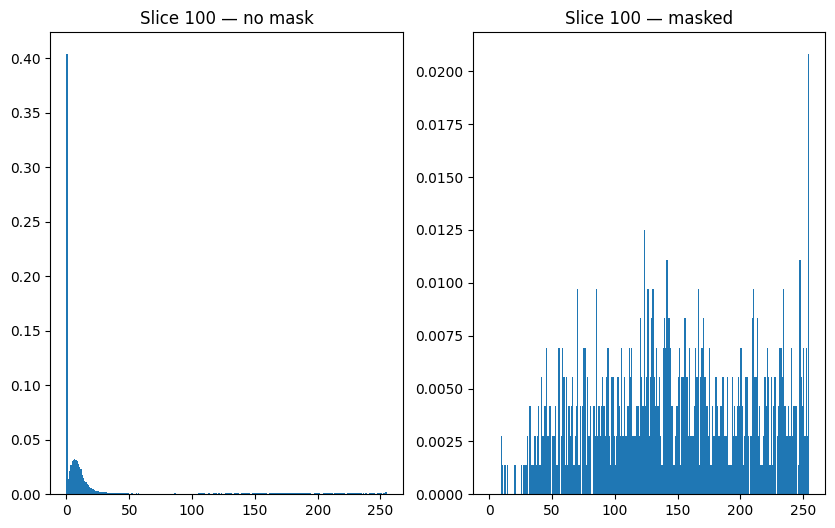

In [20]:
single_slice_hist(t1_data, mask_data, slice_idx=100)

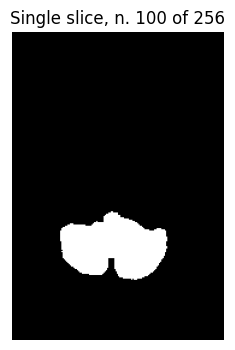

In [21]:
display_single_slice(mask_data, slice_idx=100, axis="axial")

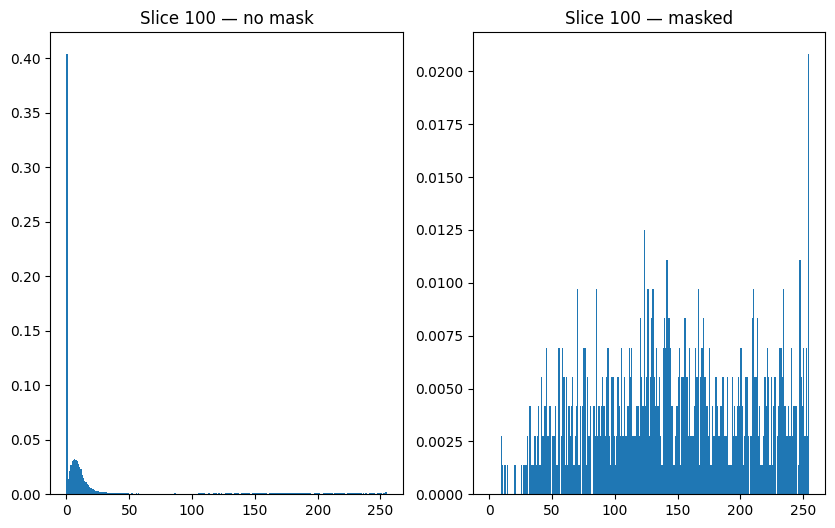

In [22]:
single_slice_hist(t1_data, mask_data, slice_idx=100, axis="axial")

## FMRI Analysis

In [23]:
# last number of voxel_size = repetition time, time between each 3d scanning of the brain
fmri_img, fmri_hdr, fmri_data, fmri_dims = load_and_display(FMRI_PATH, "FMRI")


INFORMATION ABOUT FMRI NIFTI FILE:

----------------------------------------------------------------------------------------------------
Type of variable nii_img: <class 'nibabel.nifti1.Nifti1Image'>
Type of variable nii_hdr: <class 'nibabel.nifti1.Nifti1Header'>
Shape of the NIfTI image: (64, 64, 36, 200)
Dimensions of the NIfTI image: [ 4 64 64 36]
Dimensions of NIfTI img data: (64, 64, 36, 200)
Voxel size (mm): (3.594, 3.594, 3.78, 3.56)


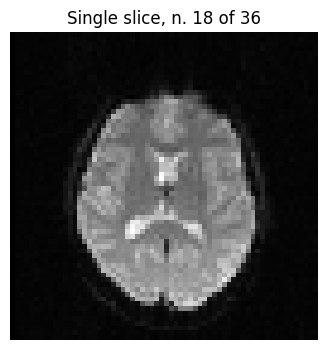

In [24]:
display_single_slice(fmri_data, slice_idx=18, axis="axial", time_instant=150)

In [32]:
num_of_timepts = fmri_data.shape[3]
acquisition_duration = num_of_timepts * fmri_dims[3]
print(f"The total acquisition is {float(acquisition_duration)} seconds long")

The total acquisition is 7200.0 seconds long


## MNI Analysis

In [25]:
mni_img, mni_hdr, mni_data, mni_dims = load_and_display(MNI_PATH, "MNI")


INFORMATION ABOUT MNI NIFTI FILE:

----------------------------------------------------------------------------------------------------
Type of variable nii_img: <class 'nibabel.nifti1.Nifti1Image'>
Type of variable nii_hdr: <class 'nibabel.nifti1.Nifti1Header'>
Shape of the NIfTI image: (91, 109, 91)
Dimensions of the NIfTI image: [  3  91 109  91]
Dimensions of NIfTI img data: (91, 109, 91)
Voxel size (mm): (2.0, 2.0, 2.0)


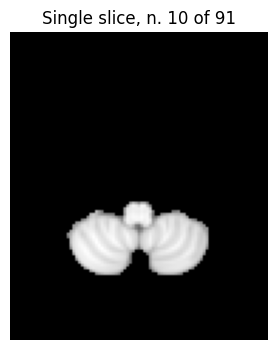

In [26]:
display_single_slice(mni_data, slice_idx=10, axis="axial")

## ATLAS Analysis

In [27]:
atlas_img, atlas_hdr, atlas_data, atlas_dims = load_and_display(ATLAS_PATH, "ATLAS")


INFORMATION ABOUT ATLAS NIFTI FILE:

----------------------------------------------------------------------------------------------------
Type of variable nii_img: <class 'nibabel.nifti1.Nifti1Image'>
Type of variable nii_hdr: <class 'nibabel.nifti1.Nifti1Header'>
Shape of the NIfTI image: (91, 109, 91)
Dimensions of the NIfTI image: [  3  91 109  91]
Dimensions of NIfTI img data: (91, 109, 91)
Voxel size (mm): (2.0, 2.0, 2.0)


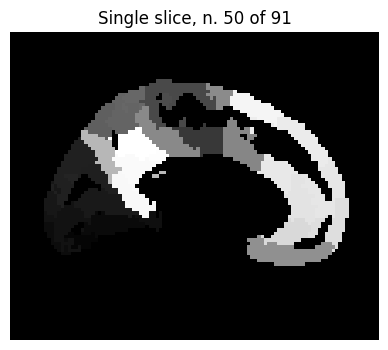

In [28]:
display_single_slice(atlas_data, slice_idx=50, axis="coronal")

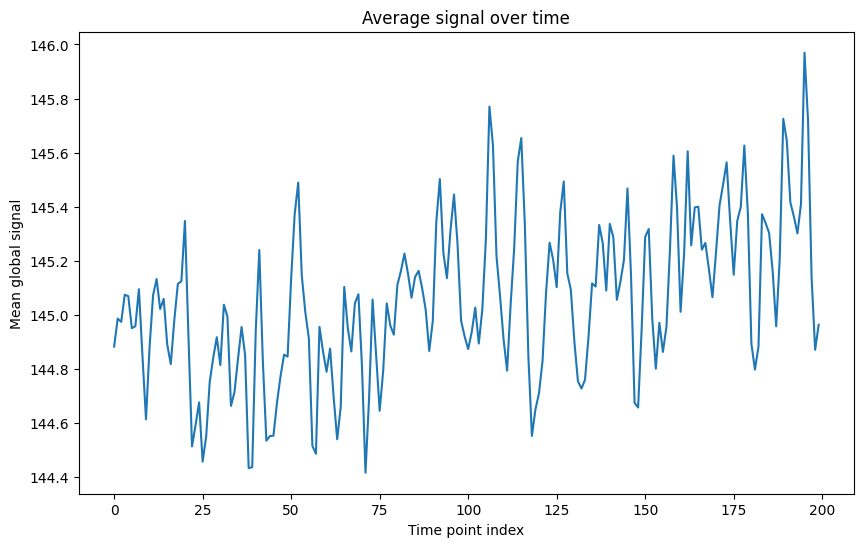

array([144.88210042, 144.98569065, 144.97358534, 145.0740153 ,
       145.06878662, 144.95029704, 144.95766873, 145.09457737,
       144.84831407, 144.61294217, 144.87849935, 145.07161458,
       145.13216824, 145.02134874, 145.0585734 , 144.88970947,
       144.81741672, 144.98054335, 145.11437988, 145.12392171,
       145.34697808, 144.91570367, 144.51285807, 144.59197998,
       144.67567952, 144.45667182, 144.54988607, 144.75134277,
       144.84142388, 144.9169515 , 144.81377496, 145.03705512,
       144.99369982, 144.66279433, 144.7146403 , 144.83878581,
       144.95479329, 144.85011122, 144.43252224, 144.43621826,
       144.93965658, 145.23961724, 144.83018663, 144.53409153,
       144.55119493, 144.55259196, 144.67504205, 144.77231852,
       144.85224067, 144.84531657, 145.13376872, 145.37282308,
       145.48902724, 145.14573161, 145.00970459, 144.91238064,
       144.51471625, 144.48588732, 144.95513238, 144.86451552,
       144.78927951, 144.87482368, 144.69630941, 144.53

In [54]:
avg_signal_along_time(fmri_data)